# 공통 정의

In [25]:
from __future__ import annotations
from typing import Callable
from pathlib import Path
import random
import os

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch import optim
import matplotlib.pyplot as plt
import numpy as np
from torch.optim.lr_scheduler import LRScheduler

PROJECT_ROOT = Path.cwd()
print(f"root is {PROJECT_ROOT}")

# 학습 환경 선택
if torch.cuda.is_available():
    device = torch.device("cuda")
else: raise RuntimeError(f"cuda is not available")

class Trainer:
    def __init__(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        valid_loader: DataLoader,
        criterion: Callable,
        optimizer: optim.Optimizer,
        device: torch.device,
        scheduler: LRScheduler | None =None,
    ):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.criterion = criterion # loss function
        self.optimizer = optimizer
        self.device = device
        self.scheduler = scheduler
        print(f"current device is {device}")
        self.train_loss_history = [] # plot용
        self.valid_loss_history = [] # plot용
        self.lr_history = []          # scheduler 확인용
        self.grad_norm_history = []
        self.train_acc_history = []  # plot용
        self.valid_acc_history = []  # plot용

    def train_one_epoch(self):
        self.model.train()

        total_loss = 0.0
        total_grad_norm = 0.0

        for x, y in self.train_loader:
            x = x.to(self.device)
            y = y.to(self.device)

            self.optimizer.zero_grad()

            pred = self.model(x)
            loss = self.criterion(pred, y)

            loss.backward()

            grad_norm = 0.0
            for p in self.model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    grad_norm += param_norm.item() ** 2

            grad_norm = grad_norm ** 0.5
            total_grad_norm += grad_norm

            self.optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(self.train_loader)
        avg_grad_norm = total_grad_norm / len(self.train_loader)

        return avg_loss, avg_grad_norm

    def validate(self):
        self.model.eval()

        total_loss = 0.0

        with torch.no_grad():
            for x, y in self.valid_loader:
                x = x.to(self.device)
                y = y.to(self.device)

                pred = self.model(x)
                loss = self.criterion(pred, y)

                total_loss += loss.item()

        return total_loss / len(self.valid_loader)
    
    def test(self, test_loader: DataLoader, is_onehot: bool):
        self.model.eval()
        
        total_loss = 0.0
        correct = 0
        total_samples = 0
        
        with torch.no_grad():
            for x, y in test_loader:
                x = x.to(self.device)
                y = y.to(self.device)
                
                pred = self.model(x)
                loss = self.criterion(pred, y)
                total_loss += loss.item()
                
                # 원-핫 인코딩(MSE 실험용)과 일반 정수형 레이블(CE 실험용) 분기 처리
                if is_onehot:
                    actual_labels = torch.argmax(y, dim=1)
                else:
                    actual_labels = y
                    
                # 예측값 중에서 가장 확률(또는 점수)이 높은 클래스 인덱스 추출
                predicted_labels = torch.argmax(pred, dim=1)
                
                # 맞춘 샘플 수 누적
                correct += (predicted_labels == actual_labels).sum().item()
                total_samples += y.size(0)
                
        avg_loss = total_loss / len(test_loader)
        accuracy = (correct / total_samples) * 100
        
        print("\n================ [TEST RESULT] ================")
        print(f"Test Loss    : {avg_loss:.4f}")
        print(f"Test Accuracy: {accuracy:.2f}% ({correct}/{total_samples})")
        print("===============================================")
        
        return avg_loss, accuracy
    
    def calculate_accuracy(self, data_loader: DataLoader, is_onehot: bool = False):
        self.model.eval()

        correct = 0
        total_samples = 0

        with torch.no_grad():
            for x, y in data_loader:
                x = x.to(self.device)
                y = y.to(self.device)

                pred = self.model(x)

                if is_onehot:
                    actual_labels = torch.argmax(y, dim=1)
                else:
                    actual_labels = y

                predicted_labels = torch.argmax(pred, dim=1)

                correct += (predicted_labels == actual_labels).sum().item()
                total_samples += y.size(0)

        accuracy = (correct / total_samples) * 100

        return accuracy

    def fit(self, epochs, is_onehot):
        for epoch in range(epochs):
            train_loss, grad_norm = self.train_one_epoch()
            valid_loss = self.validate()

            train_acc = self.calculate_accuracy(self.train_loader, is_onehot=is_onehot)
            valid_acc = self.calculate_accuracy(self.valid_loader, is_onehot=is_onehot)

            self.train_loss_history.append(train_loss)
            self.valid_loss_history.append(valid_loss)

            self.grad_norm_history.append(grad_norm)

            self.train_acc_history.append(train_acc)
            self.valid_acc_history.append(valid_acc)

            current_lr = self.optimizer.param_groups[0]["lr"]
            self.lr_history.append(current_lr)

            print(
            f"Epoch {epoch + 1}: "
            f"train_loss={train_loss:.4f}, "
            f"valid_loss={valid_loss:.4f}, "
            f"train_acc={train_acc:.2f}%, "
            f"valid_acc={valid_acc:.2f}%, "
            f"lr={current_lr:.6f}"
            )

            if self.scheduler is not None:
                self.scheduler.step()

# epoch vs loss graph
def plot_multiple_loss_curves(trainers_dict: dict[str, Trainer], title: str = "Loss Curve Comparison"):
    num_trainers = len(trainers_dict)
    if num_trainers == 0:
        raise ValueError("그릴 데이터가 없습니다.")

    fig, axes = plt.subplots(nrows=num_trainers, ncols=1, figsize=(14, 4 * num_trainers), sharex=False)
    
    if num_trainers == 1:
        axes = [axes]
        
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # 각 서브플롯마다 하나의 Trainer 데이터를 매핑하여 그리기
    for idx, (name, trainer) in enumerate(trainers_dict.items()):
        ax = axes[idx]
        epochs = range(1, len(trainer.train_loss_history) + 1)
        
        ax.plot(epochs, trainer.train_loss_history, label="Train Loss", linestyle="-", color='tab:blue')
        ax.plot(epochs, trainer.valid_loss_history, label="Valid Loss", linestyle="--", color='tab:orange')
        
        ax.set_title(f"Experiment: {name}", fontsize=12, fontweight='bold', loc='left')
        ax.set_xlabel("Epochs", fontsize=10)
        ax.set_ylabel("Loss", fontsize=10)
        if len(epochs) > 0:
            ax.set_xticks(np.arange(0, len(epochs) + 1, 20))
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend(fontsize=9, loc="upper right")
        
    plt.tight_layout()
    plt.show()

# epoch vs accuracy graph
def plot_multiple_accuracy_curves(
    trainers_dict: dict[str, Trainer],
    title: str = "Accuracy Curve Comparison"
):
    num_trainers = len(trainers_dict)
    if num_trainers == 0:
        raise ValueError("그릴 데이터가 없습니다.")

    fig, axes = plt.subplots(
        nrows=num_trainers,
        ncols=1,
        figsize=(14, 4 * num_trainers),
        sharex=False
    )

    if num_trainers == 1:
        axes = [axes]

    fig.suptitle(title, fontsize=16, fontweight="bold")

    for idx, (name, trainer) in enumerate(trainers_dict.items()):
        ax = axes[idx]
        epochs = range(1, len(trainer.train_acc_history) + 1)

        ax.plot(
            epochs,
            trainer.train_acc_history,
            label="Train Accuracy",
            linestyle="-",
            color="tab:blue"
        )

        ax.plot(
            epochs,
            trainer.valid_acc_history,
            label="Valid Accuracy",
            linestyle="--",
            color="tab:orange"
        )

        ax.set_title(
            f"Experiment: {name}",
            fontsize=12,
            fontweight="bold",
            loc="left"
        )
        ax.set_xlabel("Epochs", fontsize=10)
        ax.set_ylabel("Accuracy (%)", fontsize=10)

        if len(epochs) > 0:
            ax.set_xticks(np.arange(0, len(epochs) + 1, 20))

        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend(fontsize=9, loc="lower right")

    plt.tight_layout()
    plt.show()

# 랜덤 시드 고정 함수
def set_all_seeds(seed: int = 42):
    """
    [ Fix all random seeds for reproducibility ]
    """
    # 1. Python core seed
    random.seed(seed)
    
    # 2. Environment seed
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. NumPy seed
    np.random.seed(seed)
    
    # 4. PyTorch CPU & GPU seed
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # For multi-GPU
        
    # 5. CuDNN deterministic backend
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

root is /home/jongchanl/CV_3


### Dataset

In [21]:
from pathlib import Path

from torchvision import datasets, transforms
from sklearn.datasets import make_moons
from torch.utils.data import TensorDataset
from torch.utils.data import random_split

storage: Path = Path(PROJECT_ROOT / "storage")
FASHION_MNIST_LABEL_COUNT = 10
MAKE_MOON_LABEL_COUNT = 2

# 데이터셋 로드(Fashion Mnsit, Make Moon)
ds1_fashion_mnist = datasets.FashionMNIST(storage, train=True, download=True, transform=transforms.ToTensor())
ds1_sample_x, ds1_sample_y = ds1_fashion_mnist[0]
print("---before type conversion---")
print(f"fashion mnist x shape: {ds1_fashion_mnist.data.shape}")
print(f"fashion mnist y shape: {ds1_fashion_mnist.targets.shape}")
print(f"fashion mnist x type: {ds1_fashion_mnist.data.dtype}")
print(f"fashion mnist y type: {ds1_fashion_mnist.targets.dtype}")

make_moon_x, make_moon_y = make_moons(n_samples=1000, noise=0.1, random_state=42)
make_moon_x = torch.tensor(make_moon_x)
make_moon_y = torch.tensor(make_moon_y)
ds2_make_moon = TensorDataset(make_moon_x, make_moon_y)
print(f"make_moons x shape: {make_moon_x.shape}")
print(f"make_moons y shape: {make_moon_y.shape}")
print(f"make_moons x type: {make_moon_x.dtype}")
print(f"make_moons y type: {make_moon_y.dtype}")

def load_data_with_split(dataset: Dataset, train_ratio: float, valid_ratio: float, test_ratio: float) -> dict[str, DataLoader]:
    total_ratio = train_ratio + valid_ratio + test_ratio
    if abs(total_ratio - 1.0) > 1e-8:
        raise ValueError("sum of ratio must be 1")
    if train_ratio * valid_ratio * test_ratio < 0: raise ValueError(f"each ratio value must be positive")

    total_size = len(dataset)
    train_size = int(total_size * train_ratio)
    valid_size = int(total_size * valid_ratio)
    test_size = int(total_size * test_ratio)

    train_dataset, valid_dataset, test_dataset = random_split(dataset, [train_size, valid_size, test_size])

    return {
        "train": DataLoader(train_dataset, batch_size=32, shuffle=True),
        "valid": DataLoader(valid_dataset, batch_size=32, shuffle=True),
        "test": DataLoader(test_dataset, batch_size=32, shuffle=True)
    }

---before type conversion---
fashion mnist x shape: torch.Size([60000, 28, 28])
fashion mnist y shape: torch.Size([60000])
fashion mnist x type: torch.uint8
fashion mnist y type: torch.int64
make_moons x shape: torch.Size([1000, 2])
make_moons y shape: torch.Size([1000])
make_moons x type: torch.float64
make_moons y type: torch.int64


---
### [실험 A] 손실 함수 비교 : CrossEntropy Loss vs MSE Loss (with softmax)

1) 실험 목표
  -  MSE와 CrossEntropy가 학습 성능에 미치는 차이 분석
  - 학습 곡선의 수렴 속도, 정확도, loss 안정성 비교

2) 추천 데이터셋 :  Fashion-MNIST, Digits Dataset

3) 실험 조건
  - 동일한 네트워크 구조 및 optimizer 하에 손실함수만 변경
  - MSE Loss 사용 시 softmax를 출력층에 명시적으로 적용. CrossEntropy Loss는내부적으로 softmax 포함

예시) # MSE Loss 사용 시
   loss_fn = nn.MSELoss()
   outputs = torch.softmax(model(inputs), dim=1)

 4) 분석 포인트
  - MSE 사용 시 Gradient Vanishing 문제 분석
  - CrossEntropy의 빠른 수렴 속도와 안정성 확인
  - 최종 정확도 차이, 학습 곡선 비교

In [22]:
import torch.nn.functional as F

# MSE loss 계산을 위한 onehot encoding wrapper class 정의
class OneHotDatasetWrapper(Dataset):
    def __init__(self, subset_dataset, num_classes=FASHION_MNIST_LABEL_COUNT):
        self.subset = subset_dataset
        self.num_classes = num_classes

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        # 기존 Subset 창구에서 원본 데이터를 꺼내온 뒤
        img, label = self.subset[idx]
        # 레이블만 원-핫 인코딩으로 실시간 가공해서 반환
        onehot_label = F.one_hot(torch.tensor(label), num_classes=self.num_classes).float()
        return img, onehot_label

# 테스트용 모델 클래스 정의
class TestA(nn.Module):
    def __init__(self, output_layer: nn.Sequential):
        super().__init__()
        self.layer = nn.Sequential(
                    nn.Flatten(),
                    nn.Linear(28 * 28, 392),
                    nn.Sigmoid(), # vanishing gradient 문제를 보이기 위해 선택
                    nn.Linear(392, 256),
                    nn.Sigmoid(),
                    nn.Linear(256, 128),
                    nn.Sigmoid(),
                )
        self.output_layer = output_layer
        self.optimizer = optim.SGD(self.parameters(), lr=1e-2)

    def forward(self, x):
        x = self.layer(x)
        x = self.output_layer(x)
        return x 
    
# Dataloader 초기화
onehot_encoded_ds1 = OneHotDatasetWrapper(ds1_fashion_mnist)
encoded_dl_fm = load_data_with_split(onehot_encoded_ds1, *(0.8, 0.1, 0.1)) # onehot encoding된 dataloader
dl_fm = load_data_with_split(ds1_fashion_mnist, *(0.8, 0.1, 0.1)) # original dataloader

# loss function
mse_loss = nn.MSELoss()
ce_loss = nn.CrossEntropyLoss()

# model
set_all_seeds()
mse_model = TestA(
    nn.Sequential(
        nn.Linear(128, FASHION_MNIST_LABEL_COUNT),
        nn.Softmax(dim=1)  
    )
)
set_all_seeds()
ce_model = TestA(
    nn.Sequential(
        nn.Linear(128, FASHION_MNIST_LABEL_COUNT)
    )
)

mse_trainer = Trainer(
    model=mse_model, 
    train_loader=encoded_dl_fm["train"],
    valid_loader=encoded_dl_fm["valid"],
    criterion=mse_loss,
    optimizer=mse_model.optimizer,
    device=device
)

ce_trainer = Trainer(
    model=ce_model, 
    train_loader=dl_fm["train"],
    valid_loader=dl_fm["valid"],
    criterion=ce_loss,
    optimizer=ce_model.optimizer,
    device=device
)

mse_trainer.fit(20, True)
ce_trainer.fit(20, False)

current device is cuda
current device is cuda
Epoch 1: train_loss=0.0904, valid_loss=0.0901, train_acc=9.95%, valid_acc=9.97%, lr=0.010000
Epoch 2: train_loss=0.0901, valid_loss=0.0900, train_acc=9.95%, valid_acc=9.97%, lr=0.010000
Epoch 3: train_loss=0.0900, valid_loss=0.0900, train_acc=10.03%, valid_acc=9.65%, lr=0.010000
Epoch 4: train_loss=0.0900, valid_loss=0.0900, train_acc=10.03%, valid_acc=9.65%, lr=0.010000
Epoch 5: train_loss=0.0900, valid_loss=0.0900, train_acc=15.19%, valid_acc=14.67%, lr=0.010000
Epoch 6: train_loss=0.0900, valid_loss=0.0900, train_acc=10.00%, valid_acc=10.10%, lr=0.010000
Epoch 7: train_loss=0.0900, valid_loss=0.0900, train_acc=10.38%, valid_acc=10.08%, lr=0.010000
Epoch 8: train_loss=0.0900, valid_loss=0.0900, train_acc=10.04%, valid_acc=9.65%, lr=0.010000
Epoch 9: train_loss=0.0900, valid_loss=0.0900, train_acc=10.05%, valid_acc=9.55%, lr=0.010000
Epoch 10: train_loss=0.0900, valid_loss=0.0900, train_acc=8.90%, valid_acc=8.85%, lr=0.010000
Epoch 11: tra

### [실험 A] 결과 출력


================ [TEST RESULT] ================
Test Loss    : 0.0900
Test Accuracy: 13.15% (789/6000)

================ [TEST RESULT] ================
Test Loss    : 0.8632
Test Accuracy: 67.07% (4024/6000)


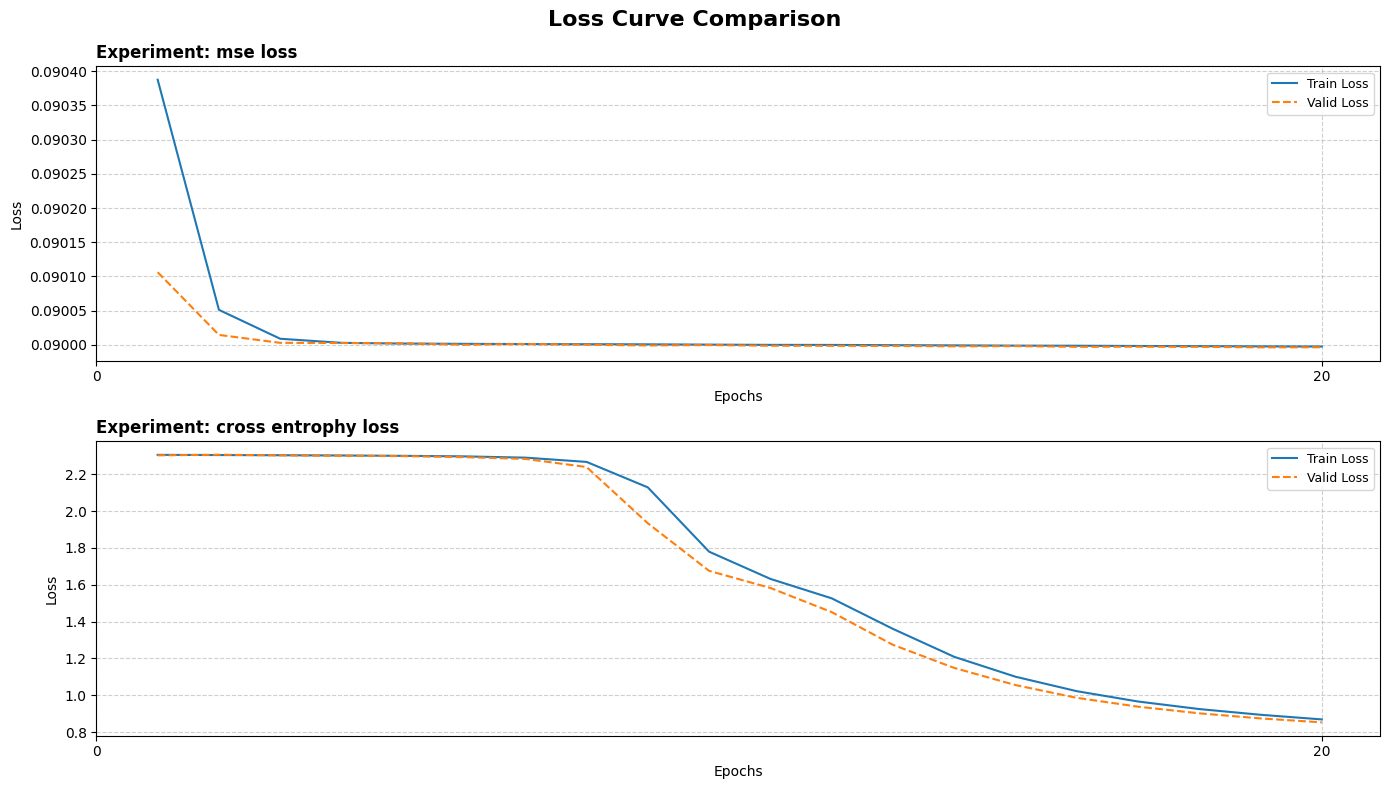

In [23]:
mse_trainer.test(encoded_dl_fm["test"], True)
ce_trainer.test(dl_fm["test"], False)

test_a_trainers = {
    "mse loss": mse_trainer,
    "cross entrophy loss": ce_trainer
}

plot_multiple_loss_curves(test_a_trainers)

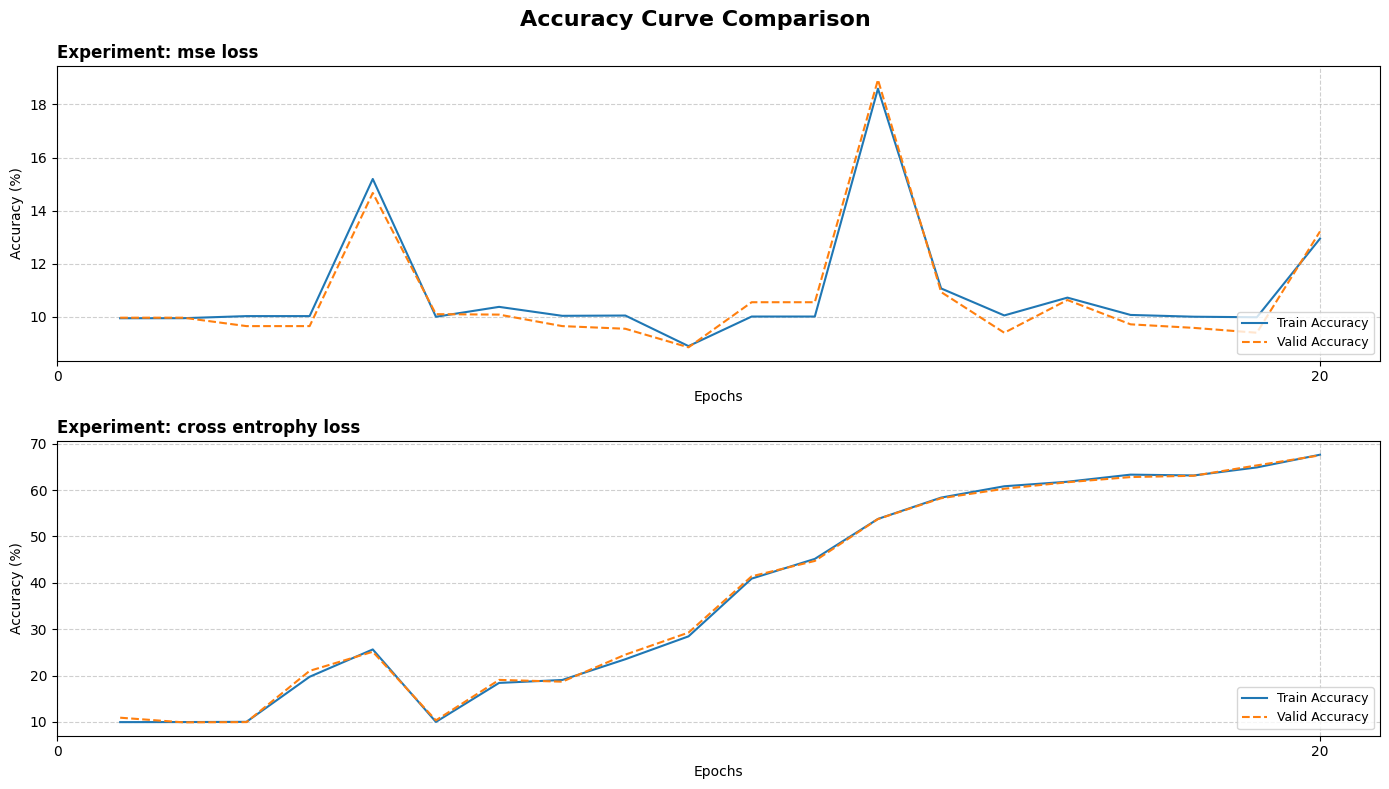

In [26]:
plot_multiple_accuracy_curves(test_a_trainers)

---
### [실험 B] 활성화 함수 비교 :  ReLU vs LeakyReLU vs Sigmoid

1) 실험 목표
  - ReLU, LeakyReLU, Sigmoid가 학습에 미치는 영향을 분석
  - Dead ReLU 발생 유도 및 LeakyReLU의 완화 효과 확인

2) 추천 데이터셋 : make_moons, make_circles 

3) 실험 조건
  - 동일 네트워크 및 손실함수(CrossEntropy), Optimizer(Adam 또는 SGD)
  - weight 초기값을 std=0.01 등 작게 설정하여 dead neuron 상황 유도

4) 분석 포인트
  - Layer별 출력값 시각화 (matplotlib 사용)
  - Sigmoid는 vanishing gradient 발생 → 학습 정체 확인
  - Dead ReLU 발생 시 어떤 지표가 정체되는지 분석
  - Dead ReLU가 발생한 neuron 비율 측정 → 히트맵 시각화
  - LeakyReLU가 Dead ReLU 문제를 얼마나 완화하는지 시각적 분석

In [34]:
import numpy as np
import seaborn as sns
import torch.nn.functional as F

# 실험 B용 데이터로더 분리 (make_moons 데이터 활용)
# 기존에 생성된 ds2_make_moon (1000, 2) 활용
dl_moon = load_data_with_split(ds2_make_moon, 0.8, 0.1, 0.1)

class TestB(nn.Module):
    """
    실험 B를 위한 범용 신경망 구조
    지정된 activation 함수에 따라 내부 레이어가 동적으로 구성됩니다.
    """
    def __init__(self, activation_fn: nn.Module):
        super().__init__()
        
        # 입력 차원 2(make_moons), 출력 차원 2(MAKE_MOON_LABEL_COUNT)
        self.features = nn.Sequential(
            nn.Linear(2, 64),
            activation_fn,
            nn.Linear(64, 64),
            activation_fn,
            nn.Linear(64, 64),
            activation_fn,
            nn.Linear(64, 64),
            activation_fn,
            nn.Linear(64, 64),
            activation_fn,
            nn.Linear(64, 64),
            activation_fn,
            nn.Linear(64, 64),
            activation_fn,
            nn.Linear(64, 64),
            activation_fn,
            nn.Linear(64, 64),
            activation_fn,
            nn.Linear(64, 64),
            activation_fn,
            nn.Linear(64, 32),
            activation_fn,
        )
        self.output_layer = nn.Linear(32, MAKE_MOON_LABEL_COUNT)
        
        # [실험 조건] 의도적으로 가중치를 매우 작게 초기화 (Dead ReLU 및 Vanishing 유도)
        self._init_weights()

    def _init_weights(self):
        """
        가중치를 std=0.01인 정규분포로 초기화하여 
        활성화 함수별 문제점이 극명하게 드러나도록 설정합니다.
        """
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.00)

    def forward(self, x):
        """
        데이터의 타입(float64 -> float32)을 맞춰주며 순전파를 진행합니다.
        """
        x = x.float()
        x = self.features(x)
        x = self.output_layer(x)
        return x

    def get_layer_outputs(self, x):
        """
        분석 포인트: 각 레이어의 활성화 값을 추적하기 위한 메서드
        """
        x = x.float()
        outputs = []
        for layer in self.features:
            x = layer(x)
            # 활성화 함수 레이어를 통과한 직후의 출력만 저장
            if not isinstance(layer, nn.Linear):
                outputs.append(x.detach().cpu())
        return outputs

# 1. 모델 개별 초기화
set_all_seeds()
model_sigmoid = TestB(nn.Sigmoid())
set_all_seeds()
model_relu = TestB(nn.ReLU())
set_all_seeds()
model_leaky = TestB(nn.LeakyReLU(negative_slope=0.01))

# 2. 공통 Optimizer 및 Criterion 설정 (CrossEntropy)
loss_fn_b = nn.CrossEntropyLoss()
lr_b = 8e-3

opt_sigmoid = optim.Adam(model_sigmoid.parameters(), lr=lr_b)
opt_relu = optim.Adam(model_relu.parameters(), lr=lr_b)
opt_leaky = optim.Adam(model_leaky.parameters(), lr=lr_b)

# 3. Trainer 인스턴스 생성 및 학습 진행 (30 Epoch)
epochs_b = 200

trainer_sigmoid = Trainer(model_sigmoid, dl_moon["train"], dl_moon["valid"], loss_fn_b, opt_sigmoid, device)
print("[Training Sigmoid Model]")
trainer_sigmoid.fit(epochs_b, False)

trainer_relu = Trainer(model_relu, dl_moon["train"], dl_moon["valid"], loss_fn_b, opt_relu, device)
print("\n[Training ReLU Model]")
trainer_relu.fit(epochs_b, False)

trainer_leaky = Trainer(model_leaky, dl_moon["train"], dl_moon["valid"], loss_fn_b, opt_leaky, device)
print("\n[Training LeakyReLU Model]")
trainer_leaky.fit(epochs_b, False)

current device is cuda
[Training Sigmoid Model]
Epoch 1: train_loss=0.6976, valid_loss=0.6955, train_acc=50.12%, valid_acc=45.00%, lr=0.008000
Epoch 2: train_loss=0.6941, valid_loss=0.6922, train_acc=49.88%, valid_acc=55.00%, lr=0.008000
Epoch 3: train_loss=0.6938, valid_loss=0.6919, train_acc=49.88%, valid_acc=55.00%, lr=0.008000
Epoch 4: train_loss=0.6935, valid_loss=0.6942, train_acc=50.12%, valid_acc=45.00%, lr=0.008000
Epoch 5: train_loss=0.6933, valid_loss=0.6931, train_acc=49.88%, valid_acc=55.00%, lr=0.008000
Epoch 6: train_loss=0.6936, valid_loss=0.6931, train_acc=50.12%, valid_acc=45.00%, lr=0.008000
Epoch 7: train_loss=0.6937, valid_loss=0.6949, train_acc=50.12%, valid_acc=45.00%, lr=0.008000
Epoch 8: train_loss=0.6932, valid_loss=0.6917, train_acc=49.88%, valid_acc=55.00%, lr=0.008000
Epoch 9: train_loss=0.6934, valid_loss=0.6913, train_acc=49.88%, valid_acc=55.00%, lr=0.008000
Epoch 10: train_loss=0.6936, valid_loss=0.6953, train_acc=50.12%, valid_acc=45.00%, lr=0.008000
E

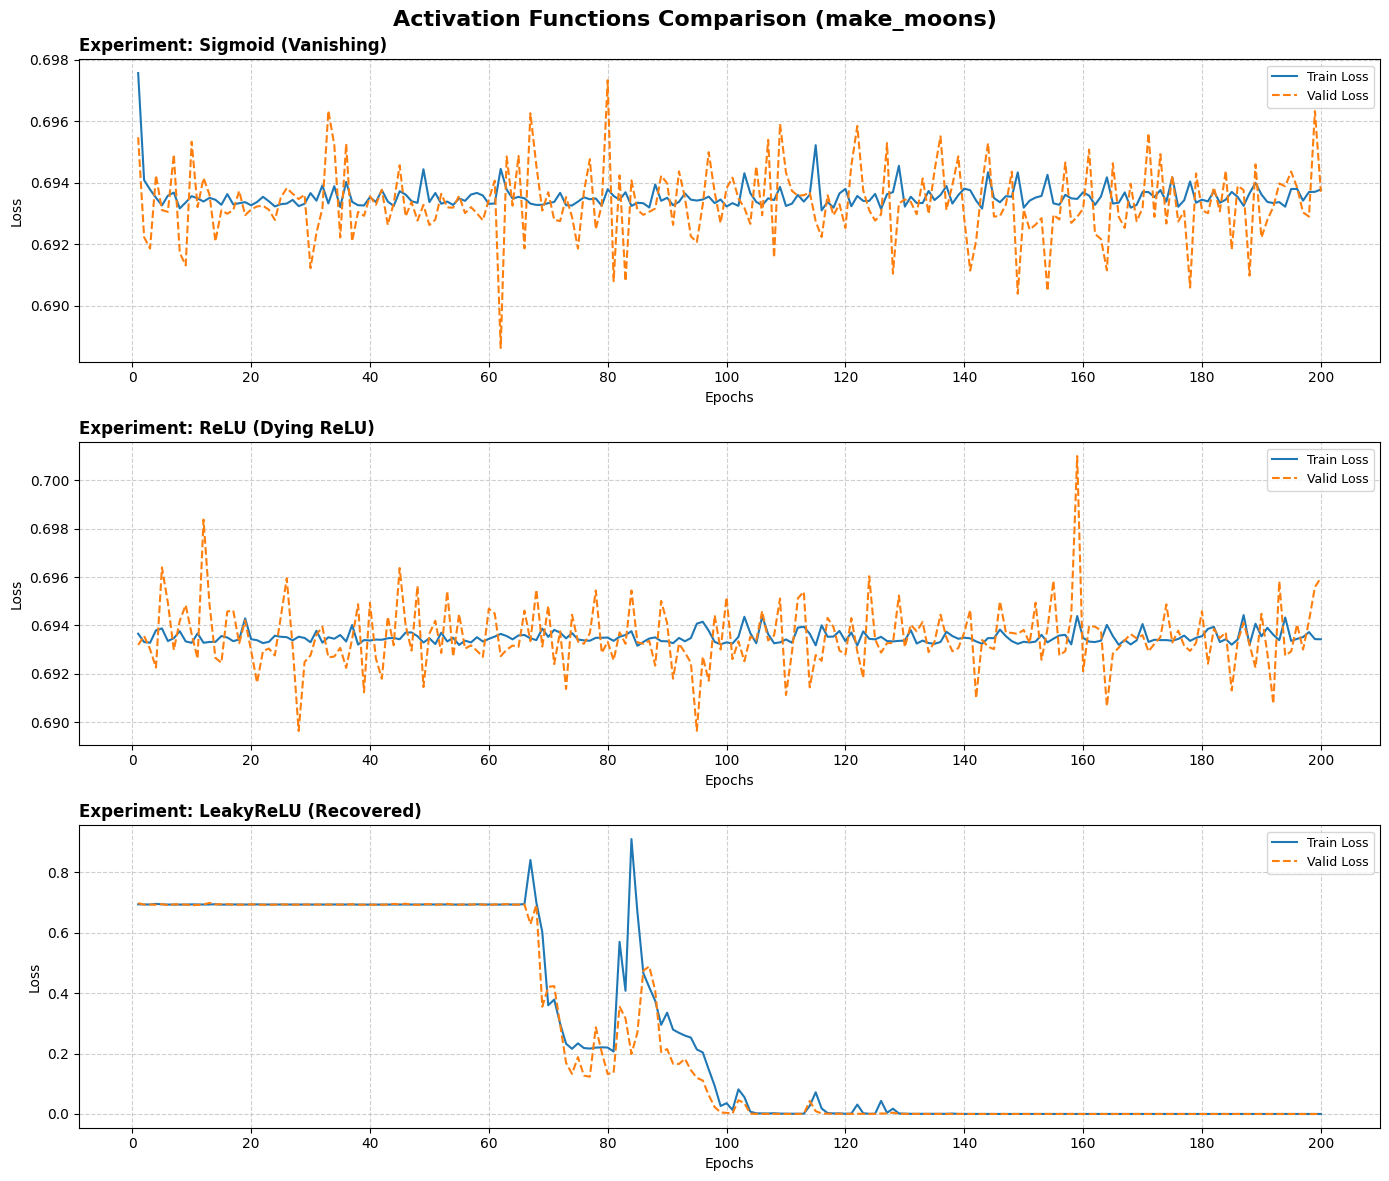

Sigmoid Test Result:

================ [TEST RESULT] ================
Test Loss    : 0.6933
Test Accuracy: 54.00% (54/100)
ReLU Test Result:

================ [TEST RESULT] ================
Test Loss    : 0.6936
Test Accuracy: 54.00% (54/100)
LeakyReLU Test Result:

================ [TEST RESULT] ================
Test Loss    : 0.0000
Test Accuracy: 100.00% (100/100)


(1.3042890259384876e-05, 100.0)

In [35]:
trainers_b_dict = {
    "Sigmoid (Vanishing)": trainer_sigmoid,
    "ReLU (Dying ReLU)": trainer_relu,
    "LeakyReLU (Recovered)": trainer_leaky
}

# Loss 커브 플롯 출력
plot_multiple_loss_curves(trainers_b_dict, title="Activation Functions Comparison (make_moons)")

# 최종 테스트 정확도 확인
print("Sigmoid Test Result:")
trainer_sigmoid.test(dl_moon["test"], is_onehot=False)
print("ReLU Test Result:")
trainer_relu.test(dl_moon["test"], is_onehot=False)
print("LeakyReLU Test Result:")
trainer_leaky.test(dl_moon["test"], is_onehot=False)

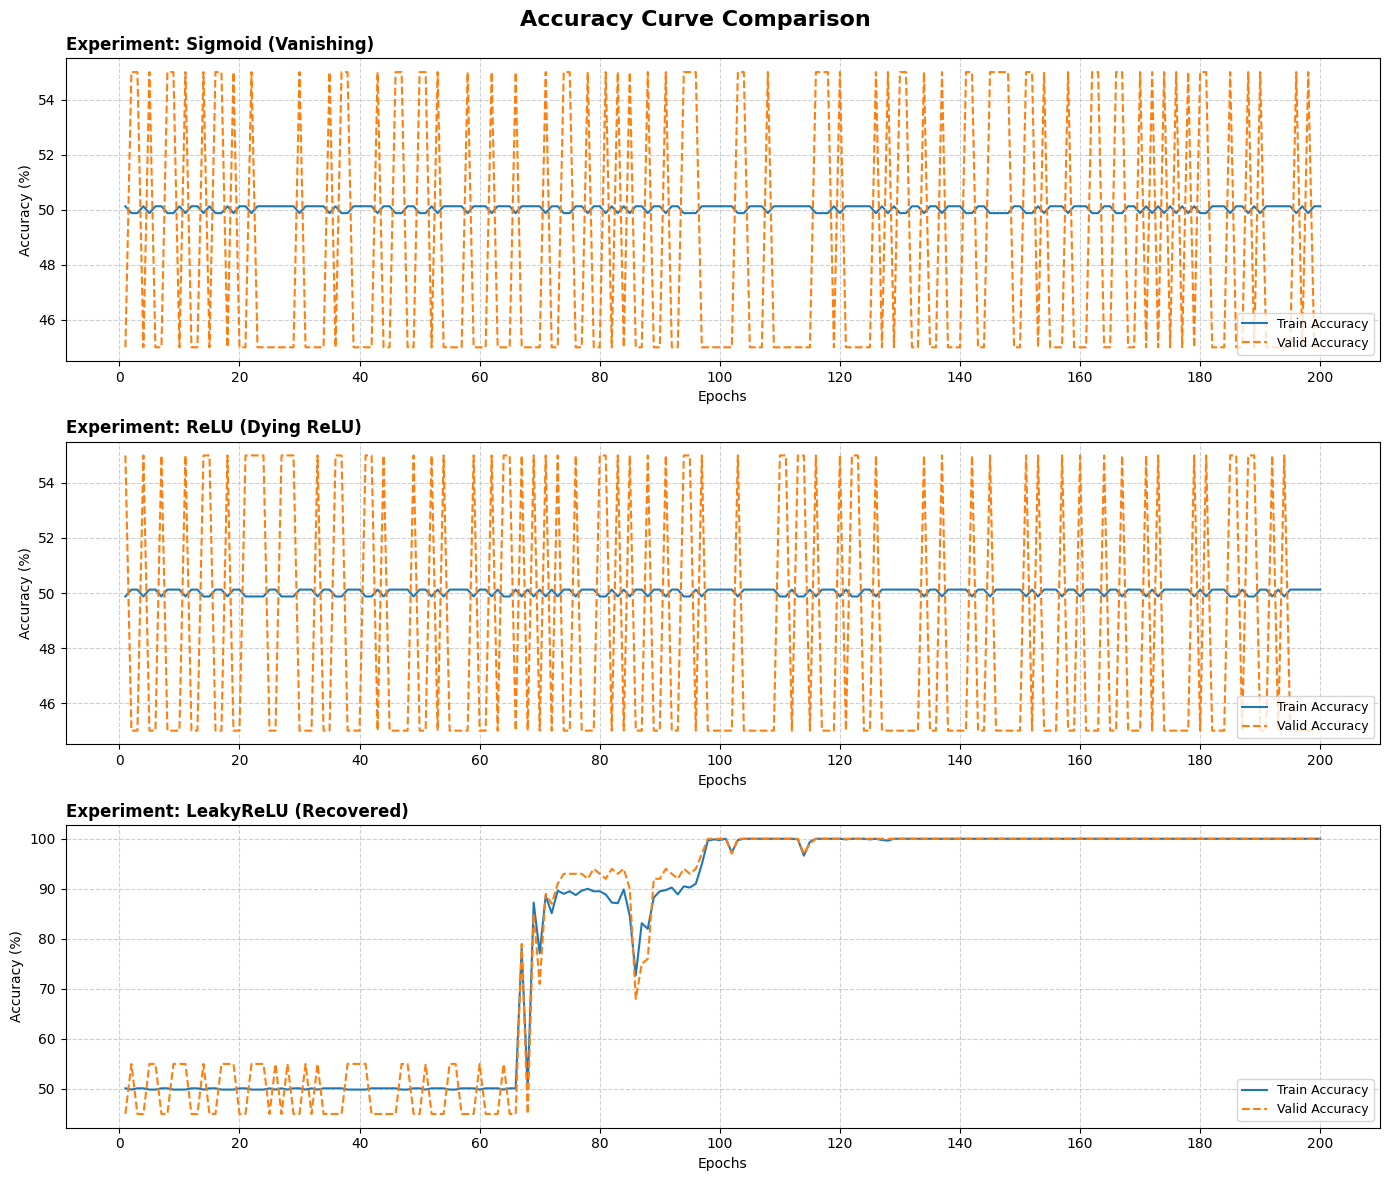

In [36]:
plot_multiple_accuracy_curves(trainers_b_dict)

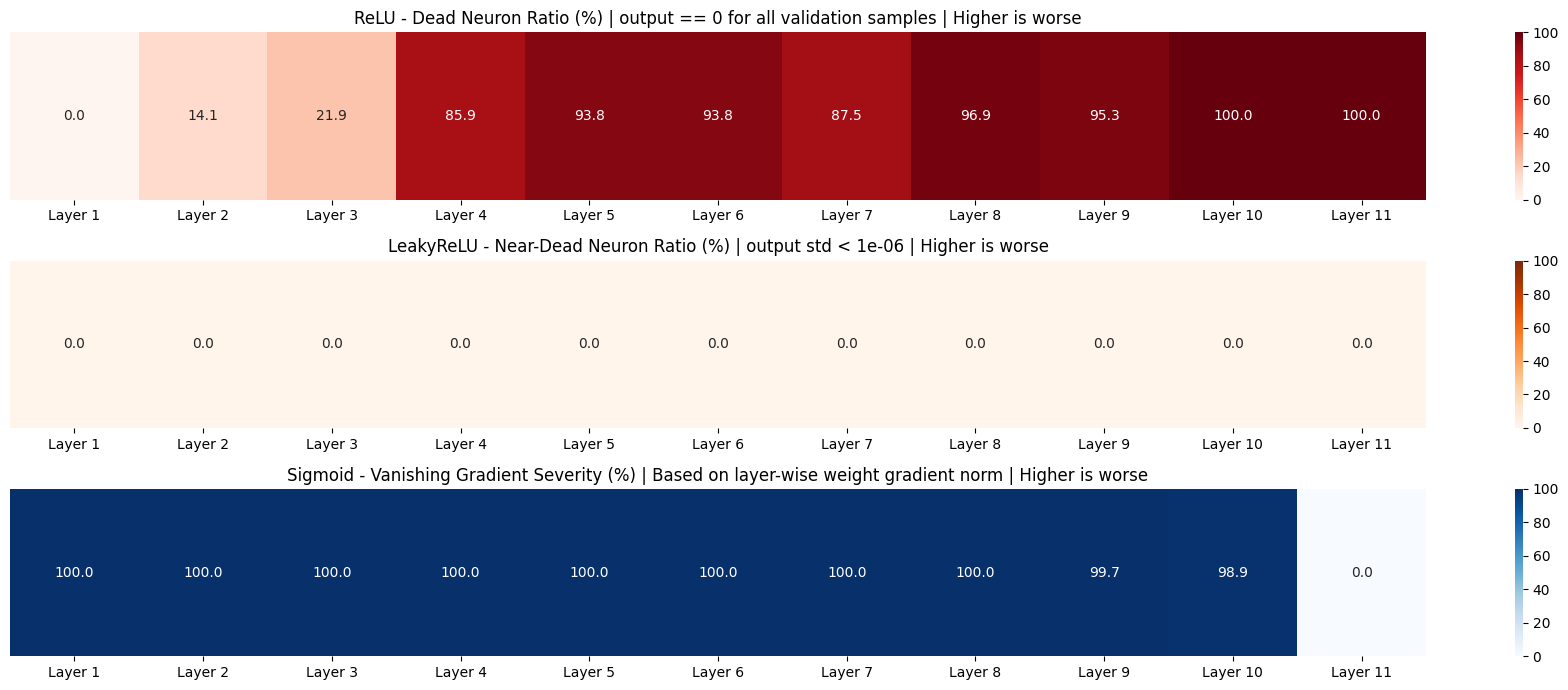

[ReLU dead neuron ratios]
Layer 01: 0.00%
Layer 02: 14.06%
Layer 03: 21.88%
Layer 04: 85.94%
Layer 05: 93.75%
Layer 06: 93.75%
Layer 07: 87.50%
Layer 08: 96.88%
Layer 09: 95.31%
Layer 10: 100.00%
Layer 11: 100.00%

[LeakyReLU near-dead neuron ratios]
Layer 01: 0.00%
Layer 02: 0.00%
Layer 03: 0.00%
Layer 04: 0.00%
Layer 05: 0.00%
Layer 06: 0.00%
Layer 07: 0.00%
Layer 08: 0.00%
Layer 09: 0.00%
Layer 10: 0.00%
Layer 11: 0.00%

[Sigmoid raw gradient norms]
Layer 01 (features.0.weight): 2.394795e-18
Layer 02 (features.2.weight): 6.789785e-16
Layer 03 (features.4.weight): 3.289653e-14
Layer 04 (features.6.weight): 2.389853e-13
Layer 05 (features.8.weight): 4.199337e-13
Layer 06 (features.10.weight): 8.949332e-13
Layer 07 (features.12.weight): 1.321791e-11
Layer 08 (features.14.weight): 4.749120e-12
Layer 09 (features.16.weight): 7.960047e-10
Layer 10 (features.18.weight): 2.583154e-09
Layer 11 (features.20.weight): 2.398527e-07


{'relu_dead_ratios': [0.0,
  14.0625,
  21.875,
  85.9375,
  93.75,
  93.75,
  87.5,
  96.875,
  95.3125,
  100.0,
  100.0],
 'leaky_near_dead_ratios': [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'sigmoid_layer_names': ['features.0.weight',
  'features.2.weight',
  'features.4.weight',
  'features.6.weight',
  'features.8.weight',
  'features.10.weight',
  'features.12.weight',
  'features.14.weight',
  'features.16.weight',
  'features.18.weight',
  'features.20.weight'],
 'sigmoid_grad_norms': [2.394795200025494e-18,
  6.789785400246134e-16,
  3.289653028063985e-14,
  2.3898529097517163e-13,
  4.199337004431175e-13,
  8.949332160751444e-13,
  1.3217912875340687e-11,
  4.749119500435661e-12,
  7.960047065935782e-10,
  2.5831543570831172e-09,
  2.398526532942924e-07],
 'sigmoid_grad_percent': [9.9844016012846e-10,
  2.830803411576681e-07,
  1.3715250874364175e-05,
  9.963796160400554e-05,
  0.0001750791345787312,
  0.000373116358155734,
  0.00551082407

In [37]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_experiment_b_diagnostics_v3(
    model_relu,
    model_leaky,
    model_sigmoid,
    data_loader,
    criterion,
    device,
    leaky_std_threshold=1e-6,
    eps=1e-12
):
    """
    Experiment B diagnostics.

    1. ReLU:
       Dead ReLU Ratio
       - 모든 validation sample에 대해 activation output == 0인 neuron 비율
       - 값이 클수록 나쁨

    2. LeakyReLU:
       Near-Dead Neuron Ratio
       - LeakyReLU는 음수에서도 정확히 0이 되지 않으므로,
         output std가 threshold보다 작은 neuron을 near-dead로 봄
       - 값이 클수록 출력 변화가 거의 없는 neuron이 많다는 뜻
       - 값이 낮을수록 ReLU의 dead 문제를 완화했다고 해석 가능

    3. Sigmoid:
       Vanishing Gradient Severity
       - validation data로 한 번 backward를 수행하여 layer별 weight gradient norm 측정
       - gradient norm이 작을수록 vanishing이 심한 것으로 봄
    """

    # -----------------------------
    # Load all validation data
    # -----------------------------
    all_x = torch.cat([x for x, _ in data_loader]).to(device)
    all_y = torch.cat([y for _, y in data_loader]).to(device)

    # -----------------------------
    # 1. ReLU / LeakyReLU forward diagnostics
    # -----------------------------
    model_relu.eval()
    model_leaky.eval()

    with torch.no_grad():
        relu_outputs = model_relu.get_layer_outputs(all_x)
        leaky_outputs = model_leaky.get_layer_outputs(all_x)

    relu_dead_ratios = []
    leaky_near_dead_ratios = []

    for relu_out, leaky_out in zip(relu_outputs, leaky_outputs):
        # ReLU dead neuron:
        # 모든 validation sample에 대해 output == 0인 neuron
        relu_dead_mask = (relu_out == 0).all(dim=0)
        relu_dead_ratio = relu_dead_mask.float().mean().item() * 100
        relu_dead_ratios.append(relu_dead_ratio)

        # LeakyReLU near-dead neuron:
        # LeakyReLU는 output == 0이 거의 발생하지 않으므로,
        # sample에 따른 output 변화량(std)이 매우 작으면 near-dead로 봄
        leaky_std = leaky_out.std(dim=0)
        leaky_near_dead_mask = leaky_std < leaky_std_threshold
        leaky_near_dead_ratio = leaky_near_dead_mask.float().mean().item() * 100
        leaky_near_dead_ratios.append(leaky_near_dead_ratio)

    # -----------------------------
    # 2. Sigmoid backward diagnostics
    # -----------------------------
    model_sigmoid.train()
    model_sigmoid.zero_grad(set_to_none=True)

    logits = model_sigmoid(all_x)
    loss = criterion(logits, all_y)
    loss.backward()

    sigmoid_grad_norms = []
    sigmoid_layer_names = []

    for name, param in model_sigmoid.named_parameters():
        if "features" in name and "weight" in name:
            if param.grad is None:
                grad_norm = 0.0
            else:
                grad_norm = param.grad.norm().item()

            sigmoid_layer_names.append(name)
            sigmoid_grad_norms.append(grad_norm)

    model_sigmoid.zero_grad(set_to_none=True)
    model_sigmoid.eval()

    # 가장 큰 gradient norm을 100으로 정규화
    max_grad = max(sigmoid_grad_norms) if len(sigmoid_grad_norms) > 0 else 0.0

    sigmoid_grad_percent = [
        (g / (max_grad + eps)) * 100 for g in sigmoid_grad_norms
    ]

    # gradient가 작을수록 vanishing이 심하므로 반전
    sigmoid_vanishing_score = [
        100 - p for p in sigmoid_grad_percent
    ]

    # -----------------------------
    # Plot
    # -----------------------------
    relu_layer_labels = [f"Layer {i+1}" for i in range(len(relu_dead_ratios))]
    leaky_layer_labels = [f"Layer {i+1}" for i in range(len(leaky_near_dead_ratios))]
    sigmoid_layer_labels = [f"Layer {i+1}" for i in range(len(sigmoid_vanishing_score))]

    fig, axes = plt.subplots(3, 1, figsize=(18, 7))

    sns.heatmap(
        np.array(relu_dead_ratios).reshape(1, -1),
        annot=True,
        fmt=".1f",
        cmap="Reds",
        vmin=0,
        vmax=100,
        xticklabels=relu_layer_labels,
        yticklabels=False,
        ax=axes[0]
    )
    axes[0].set_title(
        "ReLU - Dead Neuron Ratio (%) | output == 0 for all validation samples | Higher is worse"
    )

    sns.heatmap(
        np.array(leaky_near_dead_ratios).reshape(1, -1),
        annot=True,
        fmt=".1f",
        cmap="Oranges",
        vmin=0,
        vmax=100,
        xticklabels=leaky_layer_labels,
        yticklabels=False,
        ax=axes[1]
    )
    axes[1].set_title(
        f"LeakyReLU - Near-Dead Neuron Ratio (%) | output std < {leaky_std_threshold} | Higher is worse"
    )

    sns.heatmap(
        np.array(sigmoid_vanishing_score).reshape(1, -1),
        annot=True,
        fmt=".1f",
        cmap="Blues",
        vmin=0,
        vmax=100,
        xticklabels=sigmoid_layer_labels,
        yticklabels=False,
        ax=axes[2]
    )
    axes[2].set_title(
        "Sigmoid - Vanishing Gradient Severity (%) | Based on layer-wise weight gradient norm | Higher is worse"
    )

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Print raw values
    # -----------------------------
    print("[ReLU dead neuron ratios]")
    for i, ratio in enumerate(relu_dead_ratios):
        print(f"Layer {i+1:02d}: {ratio:.2f}%")

    print("\n[LeakyReLU near-dead neuron ratios]")
    for i, ratio in enumerate(leaky_near_dead_ratios):
        print(f"Layer {i+1:02d}: {ratio:.2f}%")

    print("\n[Sigmoid raw gradient norms]")
    for i, (layer_name, grad_norm) in enumerate(zip(sigmoid_layer_names, sigmoid_grad_norms)):
        print(f"Layer {i+1:02d} ({layer_name}): {grad_norm:.6e}")

    return {
        "relu_dead_ratios": relu_dead_ratios,
        "leaky_near_dead_ratios": leaky_near_dead_ratios,
        "sigmoid_layer_names": sigmoid_layer_names,
        "sigmoid_grad_norms": sigmoid_grad_norms,
        "sigmoid_grad_percent": sigmoid_grad_percent,
        "sigmoid_vanishing_score": sigmoid_vanishing_score,
        "leaky_std_threshold": leaky_std_threshold,
    }


diagnostic_results_b = plot_experiment_b_diagnostics_v3(
    model_relu=model_relu,
    model_leaky=model_leaky,
    model_sigmoid=model_sigmoid,
    data_loader=dl_moon["valid"],
    criterion=loss_fn_b,
    device=device,
    leaky_std_threshold=1e-6
)

diagnostic_results_b

---
### [실험 C] 최적화 알고리즘 비교 : SGD, SGD+Momentum, Adam

1) 실험 목표
  - SGD, SGD+Momentum, Adam의 성능 비교
  - 학습률 변화가 미치는 영향 분석 (0.1, 0.01, 0.001)

2) 추천 데이터셋: Fashion-MNIST, Digits Dataset 

3) 실험 조건
  - 동일한 네트워크, 손실함수, 데이터셋
  - 학습률에 따른 3개의 optimizer 성능 비교 (표로 정리)
  - Learning rate를 지수 감소 (Exponential Decay) 적용하여 실험  

     scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

4) 분석 포인트
  - Overshooting, 느린 수렴, 안정성 확인
  - 학습률 변화에 따른 Loss 곡선과 Gradient 흐름 분석

In [ ]:
import pandas as pd
from torch.optim.lr_scheduler import ExponentialLR

class TestC(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, FASHION_MNIST_LABEL_COUNT)
        )

    def forward(self, x):
        return self.layer(x)
    
# optimizer 이름과 learning rate에 따라 optimizer 생성하는 함수
def make_optimizer(optimizer_name, model, lr):
    if optimizer_name == "SGD":
        return optim.SGD(model.parameters(), lr=lr)

    elif optimizer_name == "SGD+Momentum":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    elif optimizer_name == "Adam":
        return optim.Adam(model.parameters(), lr=lr)

    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")


criterion_c = nn.CrossEntropyLoss()

optimizer_names = ["SGD", "SGD+Momentum", "Adam"]
learning_rates = [0.1, 0.01, 0.001]

epochs_c = 30

trainers_c = {}
results_c = []

for optimizer_name in optimizer_names:
    for lr in learning_rates:
        experiment_name = f"{optimizer_name} / lr={lr}"

        print(f"\n==============================")
        print(f"[Training] {experiment_name}")
        print(f"==============================")

        # 같은 초기값에서 시작하도록 seed 고정
        set_all_seeds()
        model_c = TestC()

        optimizer_c = make_optimizer(
            optimizer_name=optimizer_name,
            model=model_c,
            lr=lr
        )

        scheduler_c = ExponentialLR(
            optimizer_c,
            gamma=0.9
        )

        trainer_c = Trainer(
            model=model_c,
            train_loader=dl_fm["train"],
            valid_loader=dl_fm["valid"],
            criterion=criterion_c,
            optimizer=optimizer_c,
            scheduler=scheduler_c,
            device=device
        )

        trainer_c.fit(epochs_c, False)

        test_loss, test_acc = trainer_c.test(
            dl_fm["test"],
            is_onehot=False
        )

        trainers_c[experiment_name] = trainer_c

        results_c.append({
            "optimizer": optimizer_name,
            "initial_lr": lr,
            "final_lr": trainer_c.lr_history[-1],
            "final_train_loss": trainer_c.train_loss_history[-1],
            "final_valid_loss": trainer_c.valid_loss_history[-1],
            "test_loss": test_loss,
            "test_accuracy": test_acc
        })

results_c_df = pd.DataFrame(results_c)
results_c_df


[Training] SGD / lr=0.1
current device is cuda
Epoch 1: train_loss=0.6260, valid_loss=0.4509, grad_norm=1.6804, lr=0.100000
Epoch 2: train_loss=0.4126, valid_loss=0.3960, grad_norm=1.5416, lr=0.090000
Epoch 3: train_loss=0.3640, valid_loss=0.3838, grad_norm=1.4830, lr=0.081000
Epoch 4: train_loss=0.3348, valid_loss=0.3730, grad_norm=1.4791, lr=0.072900
Epoch 5: train_loss=0.3125, valid_loss=0.3460, grad_norm=1.4696, lr=0.065610
Epoch 6: train_loss=0.2961, valid_loss=0.3351, grad_norm=1.4899, lr=0.059049
Epoch 7: train_loss=0.2801, valid_loss=0.3319, grad_norm=1.4932, lr=0.053144
Epoch 8: train_loss=0.2681, valid_loss=0.3323, grad_norm=1.5187, lr=0.047830
Epoch 9: train_loss=0.2557, valid_loss=0.3115, grad_norm=1.5336, lr=0.043047
Epoch 10: train_loss=0.2457, valid_loss=0.3115, grad_norm=1.5585, lr=0.038742
Epoch 11: train_loss=0.2363, valid_loss=0.3137, grad_norm=1.5748, lr=0.034868
Epoch 12: train_loss=0.2280, valid_loss=0.3040, grad_norm=1.6034, lr=0.031381
Epoch 13: train_loss=0.22

,optimizer,initial_lr,final_lr,final_train_loss,final_valid_loss,test_loss,test_accuracy
0,SGD,0.100,0.004710,0.151844,0.296386,0.265306,90.400000
1,SGD,0.010,0.000471,0.367435,0.399946,0.384676,86.483333
2,SGD,0.001,0.000047,0.705551,0.704609,0.705374,74.483333
3,SGD+Momentum,0.100,0.004710,0.223591,0.389284,0.350345,88.450000
4,SGD+Momentum,0.010,0.000471,0.152123,0.298063,0.270075,90.050000
5,SGD+Momentum,0.001,0.000047,0.367775,0.400377,0.385154,86.483333
6,Adam,0.100,0.004710,2.303293,2.315705,2.303302,9.783333
7,Adam,0.010,0.000471,0.212692,0.466198,0.436673,88.616667
8,Adam,0.001,0.000047,0.090238,0.359944,0.326360,90.450000


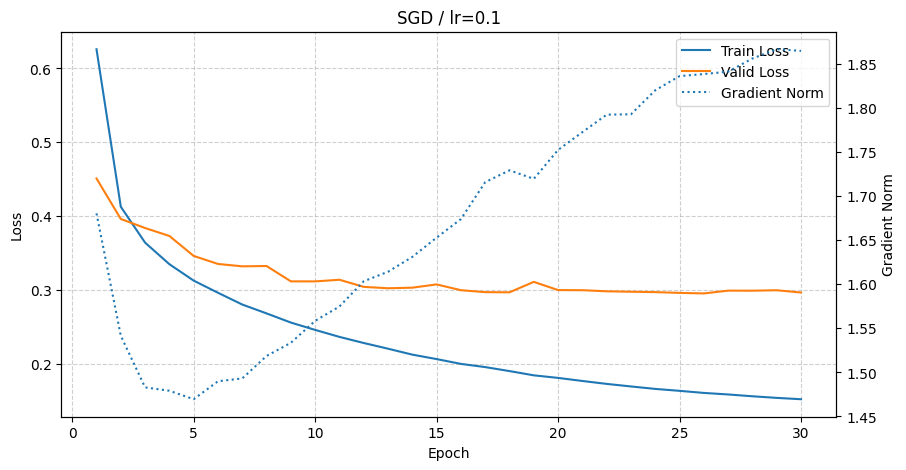

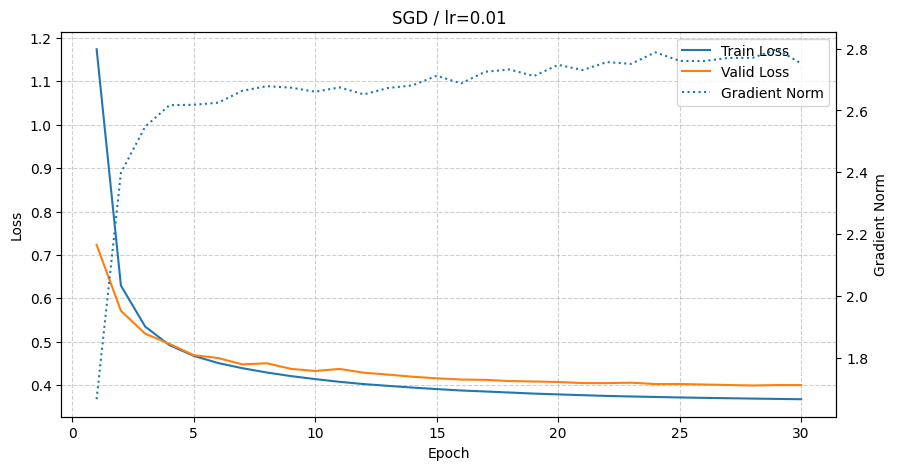

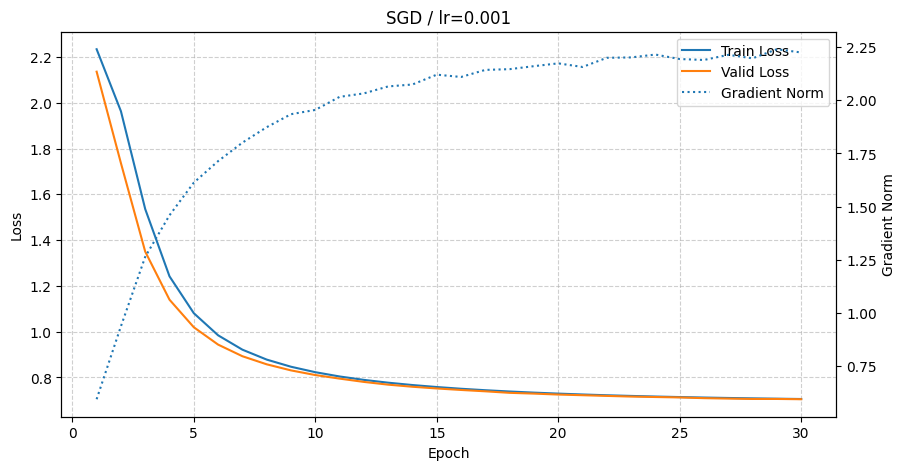

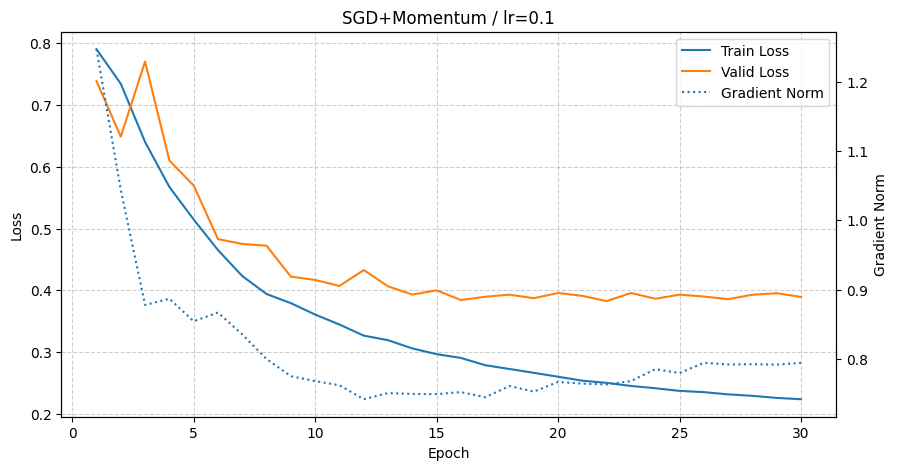

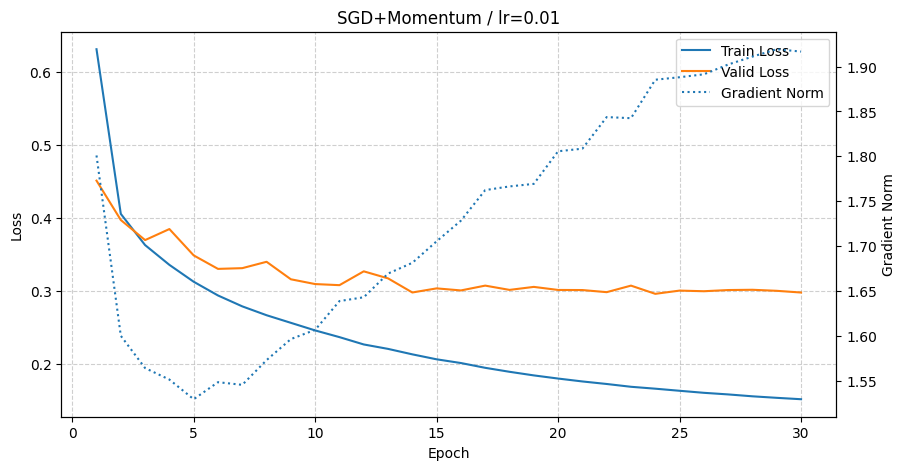

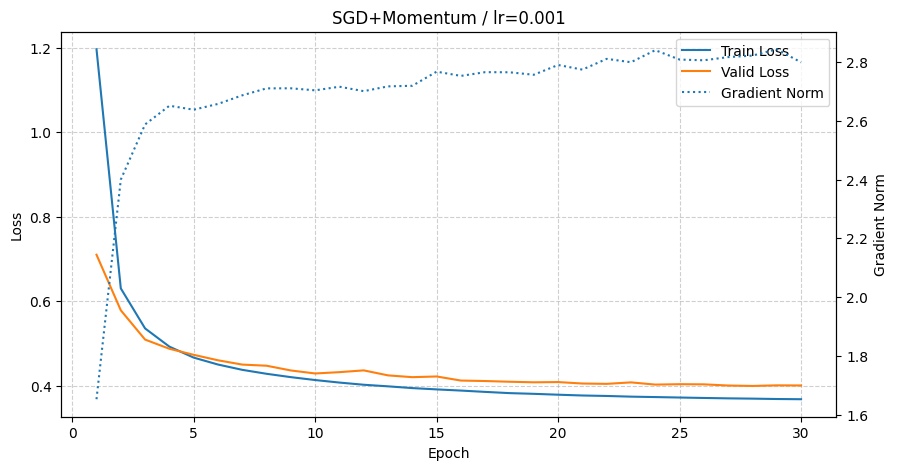

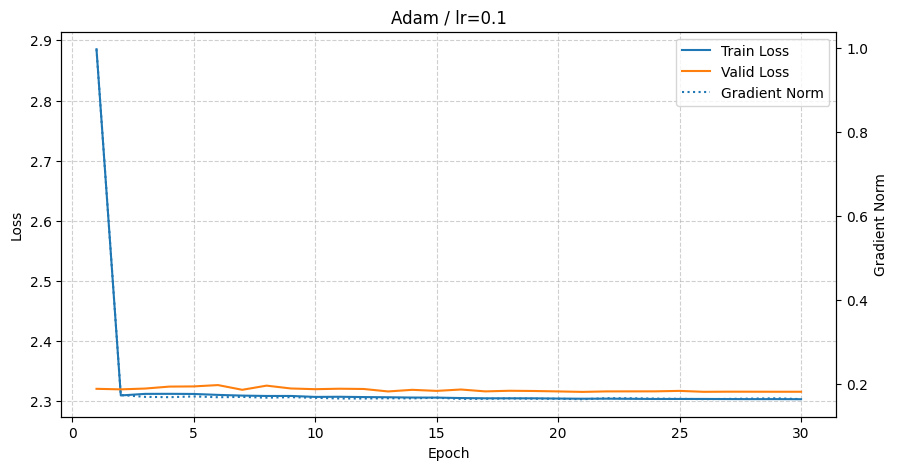

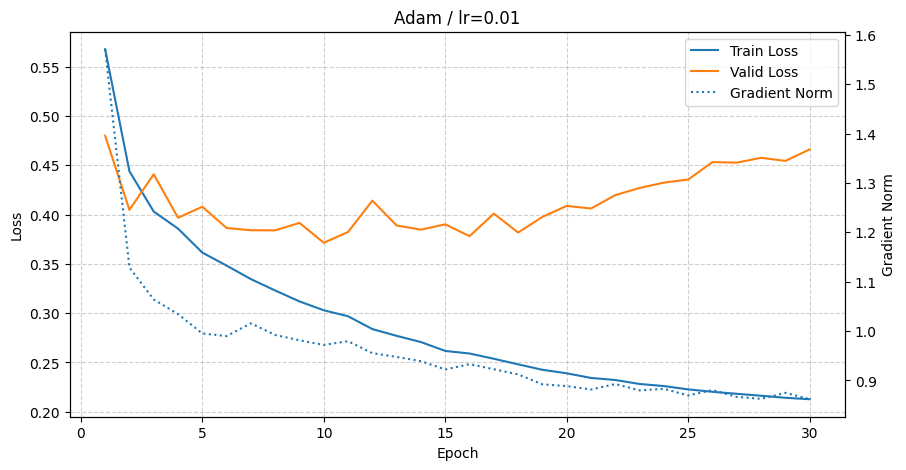

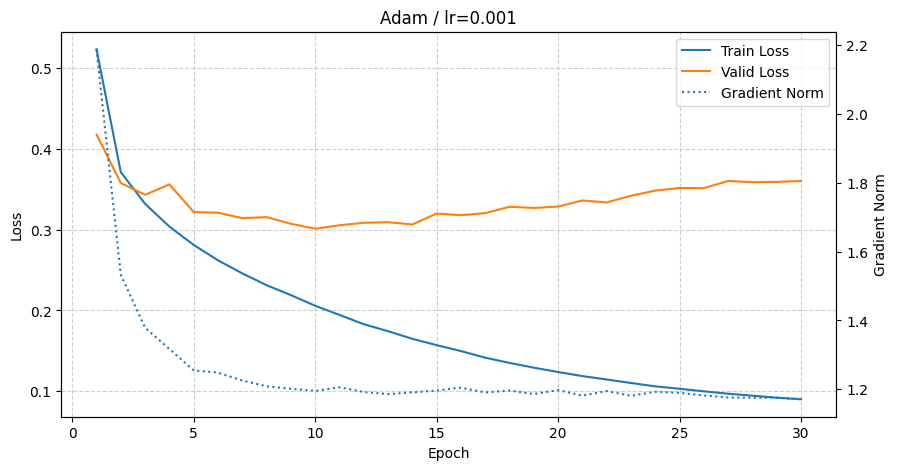

In [19]:
def plot_loss_and_gradient(trainers_dict):
    for name, trainer in trainers_dict.items():
        epochs = range(1, len(trainer.train_loss_history) + 1)

        fig, ax1 = plt.subplots(figsize=(10, 5))

        ax1.plot(epochs, trainer.train_loss_history, label="Train Loss")
        ax1.plot(epochs, trainer.valid_loss_history, label="Valid Loss")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Loss")
        ax1.grid(True, linestyle="--", alpha=0.6)

        ax2 = ax1.twinx()
        ax2.plot(epochs, trainer.grad_norm_history, label="Gradient Norm", linestyle=":")
        ax2.set_ylabel("Gradient Norm")

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2)

        plt.title(name)
        plt.show()

plot_loss_and_gradient(trainers_c)